# Stage 03 · Step 1 — Train per-printer τ policy with PPO

Frozen Stage 02 PatchTST encoder → 275-d observation (encoder + city one-hot + climate stats) → `MlpPolicy` → 6-d Gaussian over τ.

Reward (training): `-(annual_cost/1e6 + 100·deficit)` — soft Lagrangian on the 95% availability constraint, gradient-friendly near the boundary. Eval reward uses the strict `INFEASIBLE_FLOOR` rule from `lib.objective.scalar_objective` (same contract as Stages 01 & 02).

Warm-start: the policy mean is initialised from Stage 02's `best_tau_surrogate.yaml` if available, so the agent starts from the surrogate optimum and PPO refines per-printer.

In [1]:
from __future__ import annotations
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

from ml_models import PROJECT_ROOT
from ml_models.lib.data import (
    DEFAULT_FLEET_PATH,
    TRAIN_PRINTERS,
    VAL_PRINTERS,
    filter_printers,
    load_fleet,
)
from ml_models.lib.env_runner import default_dates
from ml_models.lib.features import build_feature_matrix
from ml_models.lib.rl import (
    MaintenanceBanditEnv,
    PPOConfig,
    load_ssl_encoder,
    random_encoder_bundle,
    set_torch_threads,
    train_ppo,
)
from sdg.generate import load_configs
from sdg.schema import COMPONENT_IDS

STAGE_DIR = PROJECT_ROOT / 'ml_models/03_rl+ssl'
MODELS_DIR = STAGE_DIR / 'models'
RESULTS_DIR = STAGE_DIR / 'results'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

STAGE_02_BEST = PROJECT_ROOT / 'ml_models/02_ssl/results/best_tau_surrogate.yaml'

# Limit torch threads — the simulator is the bottleneck and torch threading
# competes with it for cores.
set_torch_threads(1)

from ml_models.lib.fast import BANDIT_PPO_TIMESTEPS, banner
banner()


In [2]:
fleet = load_fleet(DEFAULT_FLEET_PATH)
_, feature_cols = build_feature_matrix(filter_printers(fleet, [0]))
try:
    bundle = load_ssl_encoder()
    print(f'Loaded Stage 02 encoder — d_model={bundle.d_model}')
except FileNotFoundError as exc:
    warnings.warn(f'{exc}\nFalling back to random encoder.')
    bundle = random_encoder_bundle(feature_columns=feature_cols, d_model=64, device='cpu')

components_cfg, couplings_cfg, cities_cfg = load_configs()

Loaded Stage 02 encoder — d_model=256


## Hackathon-friendly defaults

We train on a 2-year sub-horizon (`TRAIN_DATES`) to keep each simulator call to a few hundred ms; validation runs on the full 10-year horizon for an apples-to-apples comparison with Stages 01 & 02. Costs are per-printer-annual so the metric scale is unchanged, but variance is higher on the short horizon — that's what the entropy term + many printers compensate for.

Tune `TRAIN_PRINTER_SUBSET` and `total_timesteps` for the wall-clock you can afford.

In [3]:
DATES_FULL = default_dates()
TRAIN_DATES = DATES_FULL[:730]   # 2 years for fast PPO rollouts
VAL_DATES = DATES_FULL            # full horizon for apples-to-apples val

TRAIN_PRINTER_SUBSET = list(TRAIN_PRINTERS[:30])  # 30/70 train printers
VAL_PRINTER_SUBSET = list(VAL_PRINTERS)            # all 15 val printers

ppo_cfg = PPOConfig(
    total_timesteps=BANDIT_PPO_TIMESTEPS,  # was 2_000; toggled by FAST_MODE
    n_steps=64,
    batch_size=64,
    n_epochs=8,
    learning_rate=3e-4,
    clip_range=0.2,
    ent_coef=0.01,
    gamma=1.0,
    gae_lambda=1.0,
    seed=42,
    net_arch=(128, 128),
    log_std_init=-1.0,
    val_eval_every=320,  # ~5 PPO updates between val sweeps
)
ppo_cfg

PPOConfig(total_timesteps=2000, n_steps=64, batch_size=64, n_epochs=8, learning_rate=0.0003, clip_range=0.2, ent_coef=0.01, vf_coef=0.5, max_grad_norm=0.5, gamma=1.0, gae_lambda=1.0, seed=42, net_arch=(128, 128), log_std_init=-1.0, val_eval_every=320)

In [4]:
train_env = MaintenanceBanditEnv(
    printer_ids=TRAIN_PRINTER_SUBSET,
    encoder_bundle=bundle,
    components_cfg=components_cfg,
    couplings_cfg=couplings_cfg,
    cities_cfg=cities_cfg,
    dates=TRAIN_DATES,
)
val_env = MaintenanceBanditEnv(
    printer_ids=VAL_PRINTER_SUBSET,
    encoder_bundle=bundle,
    components_cfg=components_cfg,
    couplings_cfg=couplings_cfg,
    cities_cfg=cities_cfg,
    dates=VAL_DATES,
)
print('train printers:', len(TRAIN_PRINTER_SUBSET), 'val printers:', len(VAL_PRINTER_SUBSET))

train printers: 30 val printers: 15


## Warm-start from Stage 02's surrogate winner

If the surrogate τ is on disk, initialise the policy mean to that τ. PPO refines from there — vastly faster than learning from a centred prior.

In [5]:
warm_tau = None
if STAGE_02_BEST.exists():
    with STAGE_02_BEST.open() as handle:
        payload = yaml.safe_load(handle)
    warm_tau = {c: float(payload['tau_nom_h'][c]) for c in COMPONENT_IDS}
    print('Warm-starting from Stage 02 best τ:')
    for c, v in warm_tau.items():
        print(f'  {c}: {v:.1f} h')
else:
    print(f'{STAGE_02_BEST} not found — PPO will start from a centred Gaussian.')

Warm-starting from Stage 02 best τ:
  C1: 50.0 h
  C2: 540.6 h
  C3: 473.9 h
  C4: 1836.2 h
  C5: 2462.5 h
  C6: 19920.9 h


In [6]:
model, history = train_ppo(
    train_env,
    val_env,
    ppo_cfg,
    warm_start_tau=warm_tau,
    save_dir=MODELS_DIR,
)
print()
print(f'Best val value: {history.best_val_value:.3e}  at step {history.best_val_at}')
print(f'Final val value: {history.val_values[-1]:.3e}')

/home/sterry/Desktop/projects/hackupc2026/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[val @    320ts] value=1.050e+10  cost=4.675e+06  avail=0.0000  (INFEASIBLE)  <- best


[val @    640ts] value=1.050e+10  cost=4.673e+06  avail=0.0000  (INFEASIBLE)


[val @    960ts] value=1.049e+10  cost=4.649e+06  avail=0.0010  (INFEASIBLE)  <- best


[val @   1280ts] value=1.049e+10  cost=4.659e+06  avail=0.0011  (INFEASIBLE)  <- best


[val @   1600ts] value=1.049e+10  cost=4.658e+06  avail=0.0011  (INFEASIBLE)  <- best


[val @   1920ts] value=1.048e+10  cost=4.645e+06  avail=0.0015  (INFEASIBLE)  <- best



Best val value: 1.048e+10  at step 1920
Final val value: 1.049e+10


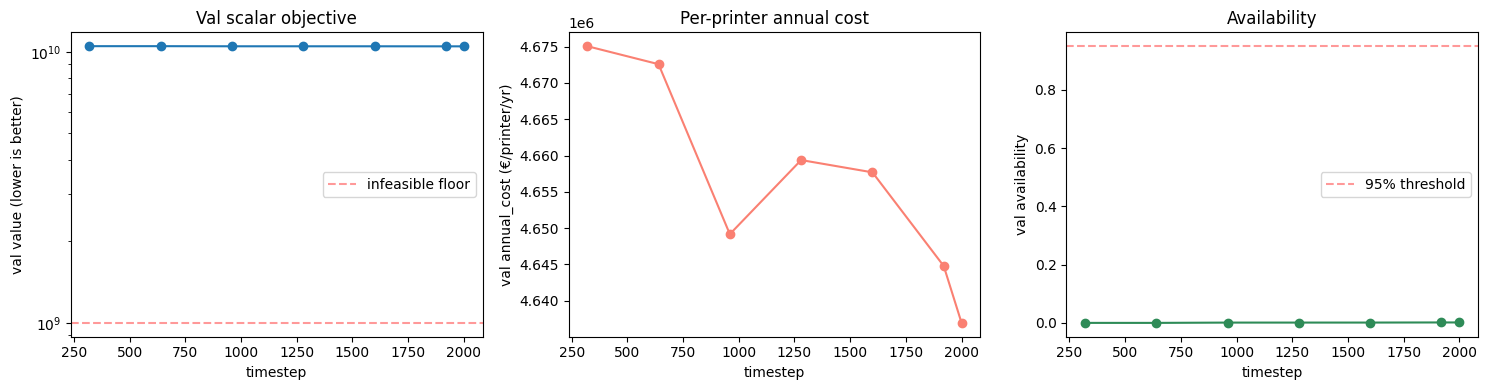

Saved curves to /home/sterry/Desktop/projects/hackupc2026/ml_models/03_rl+ssl/results/training_curves.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history.val_timesteps, history.val_values, marker='o')
axes[0].axhline(1e9, color='red', linestyle='--', alpha=0.4, label='infeasible floor')
axes[0].set_yscale('log')
axes[0].set_xlabel('timestep')
axes[0].set_ylabel('val value (lower is better)')
axes[0].set_title('Val scalar objective')
axes[0].legend()

axes[1].plot(history.val_timesteps, history.val_annual_costs, marker='o', color='salmon')
axes[1].set_xlabel('timestep')
axes[1].set_ylabel('val annual_cost (€/printer/yr)')
axes[1].set_title('Per-printer annual cost')

axes[2].plot(history.val_timesteps, history.val_availabilities, marker='o', color='seagreen')
axes[2].axhline(0.95, color='red', linestyle='--', alpha=0.4, label='95% threshold')
axes[2].set_xlabel('timestep')
axes[2].set_ylabel('val availability')
axes[2].set_title('Availability')
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

with (RESULTS_DIR / 'training_curves.json').open('w', encoding='utf-8') as handle:
    json.dump(history.to_json(), handle, indent=2)
print('Saved curves to', RESULTS_DIR / 'training_curves.png')

## Acceptance gate

- Val value should monotonically decrease (with the usual PPO noise).
- Final val availability ≥ 0.95 — otherwise the policy is infeasible and the test eval will breach `INFEASIBLE_FLOOR`. If you can't get past 0.95, narrow `TAU_RANGES` toward shorter intervals (more preventive, less corrective) or increase `total_timesteps`.
- Best policy is saved to `models/ppo_policy_best.zip`. The next notebook (`02_eval_test.ipynb`) loads it for the held-out test evaluation.